### Case Study 2

| Model | Tasks and Comments | Status | Individual Responsible |
| --- | --- | --- | --- |
| SVM w/ Bag of Words | | Done | Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Training - Model built, train and test handled correctly? | Done |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Evaluation - Confusion Matrix, what is the AUC value? | Pending |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Interpretation using Lime | Done/Pending | |
| | 1st round of tuning - What was the issue faced/tuned? | Done | |
| | 2nd round of tuning - What was the issue faced/tuned? | Done | |
| | Final AUC value? Next steps Recommended? | pending | |
| SVM w/ pre-trained embeddings | Preprocessing Steps - 1. Step 1, 2. Step 2, 3. ... | Done|  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Training - Model built, train and test handled correctly? | Done |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Evaluation - Confusion Matrix, what is the AUC value? | Done |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Interpretation using Lime | Pending | |
| | 1st round of tuning - What was the issue faced/tuned? | Pending | |
| | 2nd round of tuning - What was the issue faced/tuned? | Pending | |
| | Final AUC value? Next steps Recommended? | Pending | |
| Deep Model w/ pre-trained embeddings | Preprocessing Steps - 1. Step 1, 2. Step 2, 3. ... | Done/Pending | Group member1 |
| | Training - Model built, train and test handled correctly? | Done/Pending | Group member2 |
| | Evaluation - Confusion Matrix, what is the AUC value? | Done/Pending | Group member3 |
| | Interpretation using Lime | Done/Pending | |
| | 1st round of tuning - What was the issue faced/tuned? | Done/Pending | |
| | 2nd round of tuning - What was the issue faced/tuned? | Done/Pending | |
| | Final AUC value? Next steps Recommended? | Done/Pending | |
| Deep Model w/ embedding layer | Preprocessing Steps - 1. Step 1, 2. Step 2, 3. ... | Done |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Training - Model built, train and test handled correctly? | Done |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Evaluation - Confusion Matrix, what is the AUC value? | Pending |  Maria , Abhiyan, Aashish, Tanishq, Ashfak, Parminder, Manpreet |
| | Interpretation using Lime | Pending | |
| | 1st round of tuning - What was the issue faced/tuned? | Pending | |
| | 2nd round of tuning - What was the issue faced/tuned? | Pending | |
| | Final AUC value? Next steps Recommended? | Pending | |


| StudentID | Students | Tasks |
| --- | --- | --- |
| 500208992 | Maria Garcia | Preprocessing, SVM with BoW and Pre-Trained Embedding Model |
| 500200382 | Abhiyan Bhattarai | Preprocessing, Fine Tuning SVM with Pre-Embedding |
| 500208080 | Aashish Tangnami | Deep Model with Pre-trained Embeddings and LSTM |
| 500196894 | Mohamed Ashfak Mohamed Ifhan | Validations, Tuning with cycles, ROC, Commenting and code segmentation |
| 500209160 | Tanishq Taneja | Fine Tune Models |
| 500209812 | Manpreet Kaur | Fine Tune Models |
| 500208924 | Parminder Singh Gill | Fine Tune Models|


Understanding the given datasets.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pyarrow as pa

Using pyarrow as backend to make the pandas more efficient interms of performance.

1. Loading the dataset into dataframe.

In [2]:
df = pd.read_excel('topic_detect/topics.xlsx', dtype_backend='pyarrow')

Checking the first 5 dataset samples.

In [3]:
df.head(5)

,title,content,content_word_count,published_date,created_at,updated_at,language,article_links,total_share_count,keywords_status,...,webinar,interview,quote,meme,give_away,quiz,cities_and_states,countries,geo_locations,topic
0,Mitsubishi Motors Co. (OTCMKTS:MMTOF) Short In...,29c9689e5ed81852967ff964f16be109a37dd9ecb1f5c9...,221,2023-04-19 07:26:42,2023-04-19 07:37:59,2023-04-19 07:37:59,en,['https://www.marketbeat.com/stocks/OTCMKTS/MM...,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,business
1,Juventus off the hook! Bianconeri set to have ...,b9e3313535ffdbc2fe198572f17ce61330980dfab64324...,225,2023-04-19 06:23:09,2023-04-19 06:44:04,2023-04-19 07:49:41,en,['https://www.gazzetta.it/Calcio/Serie-A/Juven...,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,sports
2,Dodgers ponder shortstop for Betts after pater...,2e7bdbd8a033973c2309948b0b1b9de02bf7491e7b464c...,389,2023-04-18 00:00:00,2023-04-19 06:39:02,2023-04-19 06:39:02,en,<NA>,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,sports
3,"Meta lays off tech teams, battering employee m...",d4e3c5c938a4c636d40cac488f32cda1cdc02c6372a5f9...,379,2023-04-19 05:27:00,2023-04-19 06:04:15,2023-04-19 07:00:26,en,"['/', '/news/most-popular-news', '/news/econom...",1,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,technology
4,FDA clears extra COVID booster for some high-r...,cfd7f633608c252af099ccb7f4a5a02eed9e7c68efe6fb...,856,2023-04-18 02:25:12,2023-04-19 11:01:10,2023-04-19 11:01:10,en,"['https://abcnews.go.com/alerts/Vaccinations',...",0,True,...,False,False,False,False,False,False,['washington'],['united kingdom'],"[{'country': 'GB', 'coordinates': [-1.51667, 5...",health


In [4]:
df.info() # checking datatypes and entries of the dataframe.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype                 
---  ------              --------------  -----                 
 0   title               10000 non-null  string[pyarrow]       
 1   content             10000 non-null  string[pyarrow]       
 2   content_word_count  10000 non-null  int64[pyarrow]        
 3   published_date      10000 non-null  string[pyarrow]       
 4   created_at          10000 non-null  timestamp[us][pyarrow]
 5   updated_at          10000 non-null  timestamp[us][pyarrow]
 6   language            10000 non-null  string[pyarrow]       
 7   article_links       7104 non-null   string[pyarrow]       
 8   total_share_count   9999 non-null   int64[pyarrow]        
 9   keywords_status     9979 non-null   bool[pyarrow]         
 10  keywords            9979 non-null   string[pyarrow]       
 11  entities            9979 non-null   string[pyarrow]   

There is one more file in txt file format to be used with the dataframe above.
We will be importing all the text files into the dataframe that matches the content column and fetch the actual content in the .txt file to the corresponding new column as new feature.

In [5]:
text_folder = 'topic_detect/text' # file path folder

We are creating a new file_content as dictionary where content from topics.xlsx dataframe will be the key and the content from the .txt will be the values.

In [6]:
import os

files_content = {}

for filename in os.listdir(text_folder):
    if filename.endswith(".txt"):
        with open(os.path.join(text_folder, filename), 'r') as file:
            content = file.read()
            files_content[filename] = content  # store content in dictionary using filename as key

In [7]:
# we are mapping the content values to the files_content and creating a new feature called content_text.
df['content_text'] = df['content'].map(files_content)

In [8]:
df.columns

Index(['title', 'content', 'content_word_count', 'published_date',
       'created_at', 'updated_at', 'language', 'article_links',
       'total_share_count', 'keywords_status', 'keywords', 'entities',
       'sentiment', 'title_sentiment', 'keywords_ex', 'infographic',
       'case_study', 'review', 'video', 'podcast', 'webinar', 'interview',
       'quote', 'meme', 'give_away', 'quiz', 'cities_and_states', 'countries',
       'geo_locations', 'topic', 'content_text'],
      dtype='object')

Unique Topics:
<ArrowExtensionArray>
[     'business',        'sports',    'technology',        'health',
       'unknown',      'politics',        'travel', 'entertainment',
       'fashion']
Length: 9, dtype: string[pyarrow]


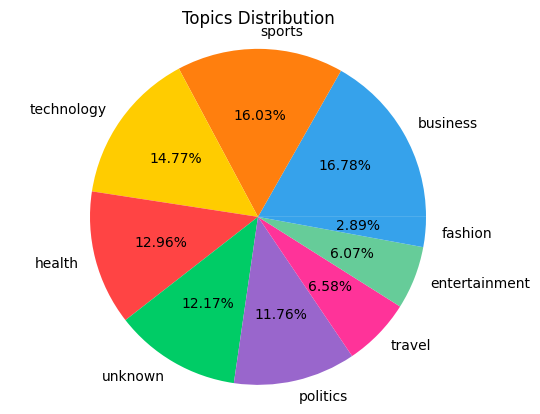

In [9]:
# chedking the unique values for the topic column - target variable

unique_topics = df['topic'].unique()
print("Unique Topics:")

print(unique_topics)
labels = unique_topics
sizes = df["topic"].value_counts()
colors = ["#36a2eb", "#ff7f0e", "#ffcc00", "#ff4444", "#00cc66", "#9966cc", "#ff3399", "#66cc99"]

plt.title("Topics Distribution")
plt.pie(sizes, labels=labels, autopct="%0.2f%%", colors=colors)
plt.axis('equal')
plt.show()

In [10]:
# checking if there are null values in the dataset
df.isna().sum()

title                    1
content                  1
content_word_count       1
published_date           1
created_at               1
updated_at               1
language                 1
article_links         2897
total_share_count        2
keywords_status         22
keywords                22
entities                22
sentiment               17
title_sentiment       4894
keywords_ex             17
infographic              3
case_study               3
review                   3
video                    3
podcast                  3
webinar                  3
interview                3
quote                    3
meme                     3
give_away                3
quiz                     3
cities_and_states     6662
countries             6662
geo_locations         6662
topic                    0
content_text           349
dtype: int64

- We can observe there are lots of NA values in different features. 
- If we drop them we will reduce the number of feature values that will lead to overfitting or underfitting of the model performance at the end.
- We will take only most important feature that will affect the topic.

In [11]:
# selecting the columns that we need for the modelling
selected_columns = ['title', 'content_text',  'topic']

df = df[selected_columns]



In [12]:
# dropping the null values
df = df.dropna()

In [13]:
df.isna().sum()

title           0
content_text    0
topic           0
dtype: int64

## Modelling
We will be using a SVM model.

In [14]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Instantiate these objects once instead of every time the function is called
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>


### Text Preprocessing
Preprocess the text data by removing special characters, punctuations, and numbers

In [15]:
# Text Preprocessing Methods

def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_usernames(text):
    return re.sub(r'@\w+', '', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_digits(text):
    return re.sub(r'\d+', '', text)

def remove_special_characters(text):
    return re.sub('[^A-Za-z0-9\s]+', '', text)

def remove_stopwords(tokenized_text):
    return [token for token in tokenized_text if token not in stop_words]

def lemmatize(tokenized_text):
    return [lemmatizer.lemmatize(token) for token in tokenized_text]

In [16]:
# modular function that cleans text.
def clean_text(text):

    text = text.lower()
    text = remove_urls(text)
    text = remove_usernames(text)
    text = remove_punctuation(text)
    text = remove_digits(text)
    text = remove_special_characters(text)
    
    tokenized_text = word_tokenize(text)
    
    tokenized_text = remove_stopwords(tokenized_text)
    tokenized_text = lemmatize(tokenized_text)
    
    cleaned_text = ' '.join(tokenized_text)

    return cleaned_text

In [17]:
df['title'] = df['title'].apply(clean_text)

In [18]:
df['content_text'] = df['content_text'].apply(clean_text)


In [19]:
df.head(5)

,title,content_text,topic
0,mitsubishi motor co otcmktsmmtof short interes...,mitsubishi motor co otcmktsmmtof get rating re...,business
1,juventus hook bianconeri set point deduction o...,new legal development could prompt reversal ju...,sports
3,meta lay tech team battering employee morale r...,oil fall u dollar strengthens fed rate hike ex...,technology
4,fda clear extra covid booster highrisk american,certain american high risk covid get extra vac...,health
5,bicep curl drop set pump gun maximize muscle gain,biceps arguably loved muscle group common hear...,unknown


In [20]:
# checking the text values in the specific row.
df.title[5], df.content_text[5]

('bicep curl drop set pump gun maximize muscle gain',
 'biceps arguably loved muscle group common hear people skip leg day youll never hear anyone missing arm day although biceps curl rank high every lifter favorite exercise list gun worth showing biceps small muscle group lifter rely curl isolation exercise add inch arm nonetheless succeed usually exerciser oscillate little much arm training regimen first technique lack training intensity spark new muscle tissue growth latter lead overtraining furthermore technique lead training plateau drop set come drop set help increase training intensity adding set rep training regimen helping ignite new muscle growth break plateau drop set boost muscle growth significantly enhancing target muscle time tension build biceps surpass people imagination must put work people fathom bicep curl drop set step right direction drop set advanced training technique faint heart muscleripping pump popular term training jargon lifter throw around like nobody bus

In [21]:
df['word_count'] = df['content_text'].apply(lambda x: len(str(x).split(" ")))
max_word_count = df['word_count'].max()
max_word_count

35871

In [22]:
df['word_count'] = df['title'].apply(lambda x: len(str(x).split(" ")))
max_word_count = df['word_count'].max()
max_word_count

34

In [23]:
df['title_content_text'] = df.apply(lambda row: f"{row['title']} {row['content_text']}", axis=1)

In [24]:
df['title_content_text'] = df['title_content_text'].apply(clean_text)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9652 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   title               9652 non-null   object         
 1   content_text        9652 non-null   object         
 2   topic               9652 non-null   string[pyarrow]
 3   word_count          9652 non-null   int64          
 4   title_content_text  9652 non-null   object         
dtypes: int64(1), object(3), string[pyarrow](1)
memory usage: 751.8+ KB


In [26]:
df.title_content_text = pd.Series(df['title_content_text'], dtype=pd.ArrowDtype(pa.string()))
df.content_text = pd.Series(df['content_text'], dtype=pd.ArrowDtype(pa.string()))

In [27]:
# Check latest word count
com_word_count = df['title_content_text'].apply(lambda x: len(str(x).split(" ")))
lem_word_count = df['title_content_text'].apply(lambda x: len(str(x).split(" ")))
com_max_word_count = com_word_count .max()
lem_max_word_count = lem_word_count .max()
eliminated = com_max_word_count - lem_max_word_count

print("Word Count \nCombined Title and Content Text:\t", com_max_word_count)
print("\nNo. of words eliminated:\t\t", eliminated)


print("\nLatest Word Count")
print("Lemmatized Text:\t\t\t", lem_max_word_count)

Word Count 
Combined Title and Content Text:	 35893

No. of words eliminated:		 0

Latest Word Count
Lemmatized Text:			 35893


In [28]:
df['count_title_content_text'] = df['title_content_text'].apply(lambda x: len(str(x).split(" ")))

In [29]:
df['count_title_content_text'].idxmax()

7387

In [30]:
df = df.drop(7387)

In [31]:
df['content_text'].idxmax() , df['title_content_text'].idxmax()

(355, 513)

In [32]:
# count the total number of words in the text in column title content text
def count_words(text):
    return len(text)

In [33]:
df.title_content_text.shape
# count the total number of words in the text in each row of title_content_text
df['word_count'] = df['title_content_text'].apply(lambda x: len(str(x).split(" ")))

<Axes: ylabel='Frequency'>

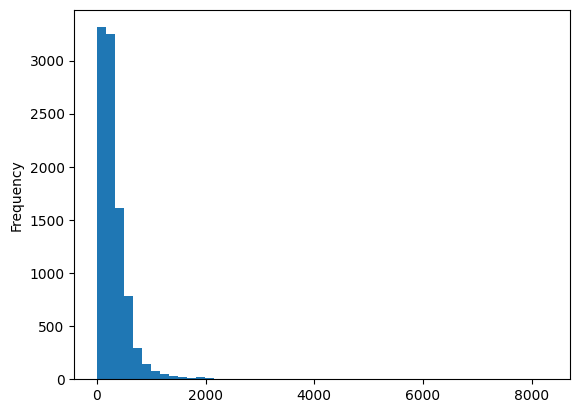

In [34]:
df['word_count']

# plot the distribution of word counts where max is 1200 and min is 0
df['word_count'].plot.hist(bins=50, range=[0, 8300])



In [35]:
# print the number of articles with word counts greater than 1000
print(sum(df['word_count'] < 10000))

9651


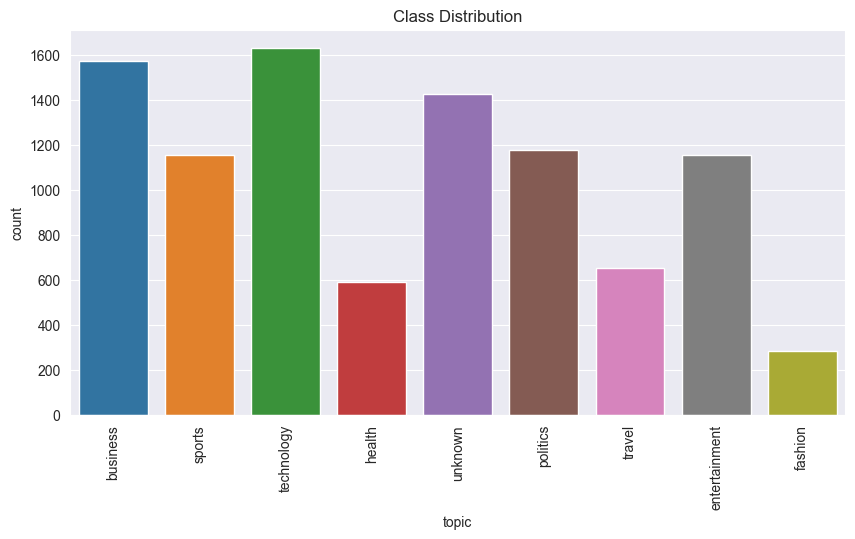

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='topic')
plt.xticks(rotation=90)
plt.title('Class Distribution')
plt.show()


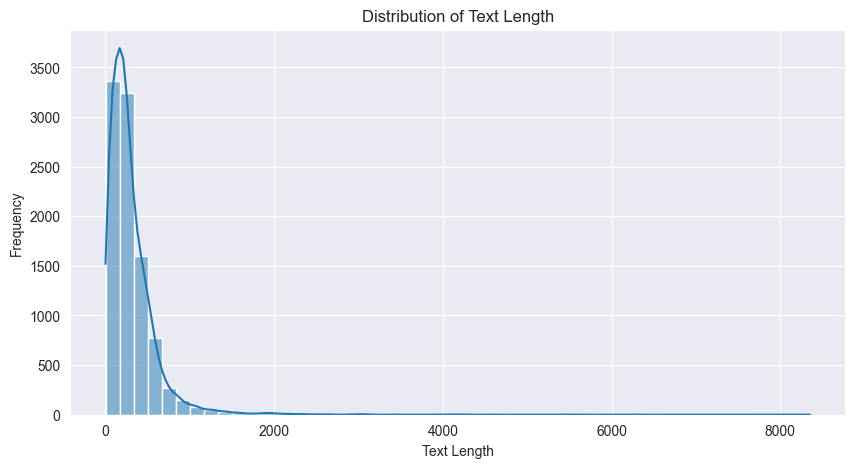

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(df['title_content_text'].apply(lambda x: len(x.split())), bins=50, kde=True)
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()


Observations:

1. From the above EDA, We can see that the text data is imbalanced.
2. The average word counts in the text values ranges from 200-8200, but only one value at index 7387 has more than 35000 words, So dropping it to prevent overfitting.
3. We will be balancing the dataset using SMOTE.

In [38]:
target_val = df.topic.unique()
target_val

<ArrowExtensionArray>
[     'business',        'sports',    'technology',        'health',
       'unknown',      'politics',        'travel', 'entertainment',
       'fashion']
Length: 9, dtype: string[pyarrow]

In [39]:
unique_words_count = len(set(" ".join(df['title_content_text']).split()))

In [40]:
unique_words_count # unique word counts.

111103

### Label Encoding for target variables.

In [41]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
le = LabelEncoder()

# Fit and transform the column in the dataframe to get encoded labels
df['is_topic'] = le.fit_transform(df['topic'])


In [42]:
df.topic.unique()

<ArrowExtensionArray>
[     'business',        'sports',    'technology',        'health',
       'unknown',      'politics',        'travel', 'entertainment',
       'fashion']
Length: 9, dtype: string[pyarrow]

### Vectorizing the text dataset with feature columns 
We are oversampling the minority classes in the training set to prevent overfitting.

In [43]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# First, split the dataset into training+validation and testing sets
X_temp, X_test, y_temp, y_test = train_test_split(df['title_content_text'], df['is_topic'], test_size=0.4, random_state=42)

# Then split the temporary set into separate training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42)

# Vectorize the text data
vectorizer = TfidfVectorizer(max_features=111103)
X_train_vect = vectorizer.fit_transform(X_train)
X_val_vect = vectorizer.transform(X_val)
X_test_vect = vectorizer.transform(X_test)

# Use SMOTE to oversample the minority classes in the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vect, y_train)


In [44]:
X_train_res.shape, y_train_res.shape

((5346, 60988), (5346,))

is_topic
5    594
0    594
1    594
6    594
8    594
4    594
7    594
3    594
2    594
Name: count, dtype: int64


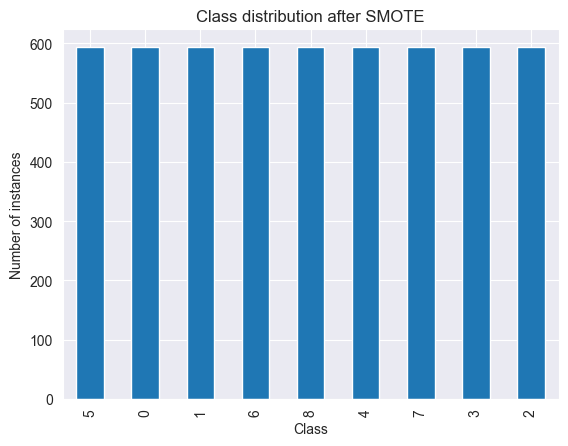

In [45]:
# Convert the resampled labels to a pandas series
y_train_res_series = pd.Series(y_train_res)

# Count the number of instances for each class
class_counts = y_train_res_series.value_counts()

# Print the class counts
print(class_counts)

# Plot a bar graph to visualize the class distribution
class_counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of instances')
plt.title('Class distribution after SMOTE')
plt.show()


### SVM model with linear kernel and bag of words.

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create an instance of the SVM classifier (SVC)
classifier = SVC(decision_function_shape='ovo', kernel='linear', gamma='auto', C=0.1)

# Train the classifier on the vectorized training data
classifier.fit(X_train_res, y_train_res)

SVC(C=0.1, decision_function_shape='ovo', gamma='auto', kernel='linear')

In [47]:
# Make predictions on the training, validation, and test data
y_train_pred = classifier.predict(X_train_res)
y_val_pred = classifier.predict(X_val_vect)
y_test_pred = classifier.predict(X_test_vect)

In [48]:
# Calculate the accuracy on each dataset
train_accuracy = accuracy_score(y_train_res, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

Training Accuracy: 0.7731013842124953
Validation Accuracy: 0.5880829015544041
Test Accuracy: 0.5915565915565916
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.38      0.49       656
           1       0.58      0.81      0.68       441
           2       0.82      0.35      0.49       114
           3       0.62      0.54      0.58       227
           4       0.58      0.81      0.68       454
           5       0.90      0.76      0.82       486
           6       0.48      0.86      0.61       640
           7       0.46      0.71      0.56       273
           8       0.78      0.07      0.13       570

    accuracy                           0.59      3861
   macro avg       0.66      0.59      0.56      3861
weighted avg       0.66      0.59      0.55      3861

Confusion Matrix:
[[246  19   2   9  73   2 236  64   5]
 [  0 358   2   2  29   3  23  23   1]
 [  0  31  40   1   1   0  33   8   0]
 [  2  18   0 122  18   0

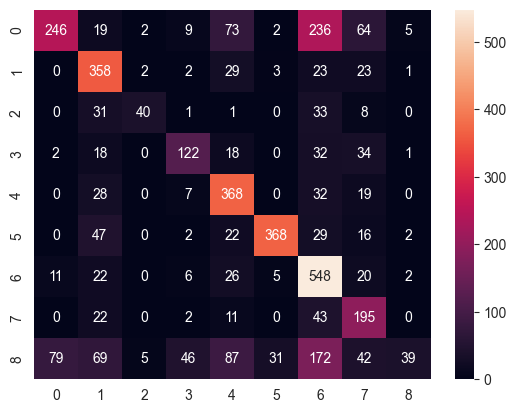

In [49]:
# Print the accuracies
print(f"Training Accuracy: {train_accuracy}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
plt.show()

Observations:

- Training vs Validation and Test Accuracy: The model has a training accuracy of approximately 0.77, which is notably higher than the validation and test accuracies (both around 0.59). This disparity suggests that the model could be overfitting to the training data, performing well on the data it was trained on but struggling to generalize to new, unseen data.
- Performance Across Classes: Precision, recall, and F1-score vary considerably across classes. For instance, class 5 demonstrates high precision (0.90), meaning when the model predicts an instance as class 5, it's usually accurate. However, classes 7 and 8 show lower precision, indicating the model often incorrectly classifies other classes as these. Class 6 has the highest recall (0.86), suggesting the model is good at identifying this class. However, classes 0, 2, 3, and 8 have lower recall values, implying the model often misses these when they are present. The F1-score, which balances precision and recall, is relatively high for classes 1, 4, 5, and 6, but it is notably low for classes 0, 2, 3, and especially 8.
- Confusion Matrix: This matrix provides further insight into the model's performance. For example, the model correctly identifies class 6 most of the time (548 out of 640 instances). However, it often confuses class 0 with class 6 (236 times). The model struggles the most with class 8, often misclassifying these instances as classes 0, 6, 1, and 4.

In summary, while this model shows promise in identifying certain classes, it's clear there is room for improvement, particularly in its ability to identify classes 0, 2, 3, and 8 and reduce its misclassification of other classes as 7 and 8. The overfitting indicated by the discrepancy between training and validation/test accuracy could be addressed by using techniques such as regularization, dropout, or collecting more data. It might also be beneficial to explore different architectures or hyperparameters for the model.

## Using Glove2word2vec pretrained word embedding.

In [50]:
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

In [51]:
filename = 'glove.6B.300d.txt' #
file_word2vec = 'word2vec.txt'
glove2word2vec(filename, file_word2vec)

/var/folders/1n/4n926d913_94f_hb0lp693200000gn/T/ipykernel_35417/779085723.py:3: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(filename, file_word2vec)


(400000, 300)

In [52]:
model = KeyedVectors.load_word2vec_format(file_word2vec, binary=False)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Tokenize and vectorize the sentences
X_vectors = []
for sentence in df['title_content_text']:
    words = sentence.split()
    sentence_vector = np.mean([model[word] for word in words if word in model.key_to_index and model[word] is not None], axis=0)
    if sentence_vector.shape[0] is not 0:  # checking if the sentence_vector is not an empty array
        X_vectors.append(sentence_vector)
    else:
        X_vectors.append(np.zeros(100))  # assuming embeddings are of size 100

X = pd.DataFrame(X_vectors) 
y = df['is_topic']

# First, split the dataset into training+validation and testing sets
X_temp, X_test, y_temp, y_test = train_test_split(X_vectors, y, test_size=0.4, random_state=42)

# Then split the temporary set into separate training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42)


<>:9: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:9: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/var/folders/1n/4n926d913_94f_hb0lp693200000gn/T/ipykernel_35417/164973698.py:9: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if sentence_vector.shape[0] is not 0:  # checking if the sentence_vector is not an empty array


In [54]:
# len(y_val)

In [55]:
# Create an instance of the SVM classifier (SVC)
classifier = SVC(decision_function_shape='ovo', kernel='linear', gamma='scale', C=0.1)

# Train the classifier on the vectorized training data
classifier.fit(X_train, y_train)

SVC(C=0.1, decision_function_shape='ovo', kernel='linear')

In [56]:
# Make predictions on the training, validation, and test data
y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)
y_test_pred = classifier.predict(X_test)

In [57]:
# Calculate the accuracy on each dataset
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

Training Accuracy: 0.6560161197466897
Validation Accuracy: 0.6230569948186528
Test Accuracy: 0.6267806267806267
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.67       656
           1       0.65      0.76      0.70       441
           2       0.80      0.25      0.38       114
           3       0.72      0.47      0.57       227
           4       0.59      0.83      0.69       454
           5       0.86      0.86      0.86       486
           6       0.62      0.70      0.66       640
           7       0.60      0.55      0.58       273
           8       0.29      0.22      0.25       570

    accuracy                           0.63      3861
   macro avg       0.65      0.59      0.59      3861
weighted avg       0.62      0.63      0.61      3861

Confusion Matrix:
[[434  13   0   3  54   2  55  26  69]
 [  3 336   1   1  29  11  22  12  26]
 [  6  27  28   2   2   1  14   3  31]
 [  5  11   0 106  28   2

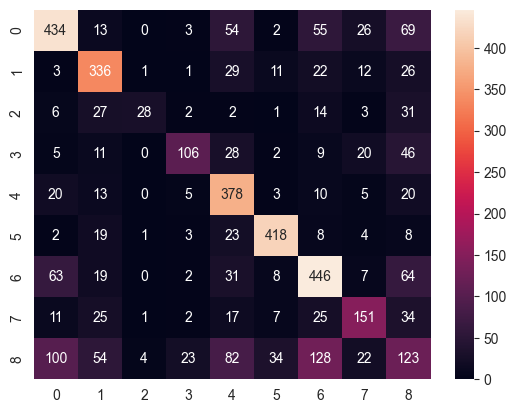

In [58]:
# Print the accuracies
print(f"Training Accuracy: {train_accuracy}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
plt.show()

Observations:
- Training vs Validation and Test Accuracy: The training accuracy is approximately 0.656, which is similar to the validation and test accuracies of 0.623 and 0.627 respectively. This consistency suggests that the model is generalizing well from the training data to unseen data.
- Precision, Recall, and F1 Score: Performance varies by class. Class 5 performs best with precision, recall, and F1 scores all at 0.86. In contrast, class 8 performs worst with a precision of 0.29, recall of 0.22, and F1 score of 0.25. Class 2 also struggles, with a recall of 0.25 leading to a lower F1 score despite high precision.
- Confusion Matrix: We can gain more insights into the misclassifications by looking at the confusion matrix. The model seems to struggle with class 8, often misclassifying it as classes 0, 6, 1, or 4. Conversely, the model performs well with class 5, correctly classifying 418 out of 486 instances.

To summarize, while the model performs reasonably well on some classes, it struggles with others. In particular, class 8 is a weak point, suggesting that it could be beneficial to revisit data collection or preprocessing for this class. Alternatively, the model architecture or training parameters could be adjusted to improve performance.

### Using Deep Neural Network - Bi-Directional LSTM

In [59]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import SpatialDropout1D

In [60]:
import tensorflow as tf  # Deep learning framework
from tensorflow.keras.layers import LSTM, Dropout, Dense, Embedding, Bidirectional  # Layers for building models
from tensorflow.keras.models import Sequential  # Sequential model
from tensorflow.keras.optimizers.legacy import Adam  # Optimization algorithm
from tensorflow.keras.callbacks import EarlyStopping  # Early stopping for model training

In [61]:
# The maximum number of words to be used. (most frequent)
MAX_NB_WORDS = 150000
# Max number of words in each complaint.
MAX_SEQUENCE_LENGTH = 800
# This is fixed.
EMBEDDING_DIM = 300
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, )
tokenizer.fit_on_texts(df['title_content_text'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 111103 unique tokens.


In [62]:
X = tokenizer.texts_to_sequences(df['title_content_text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (9651, 800)


In [63]:
y = pd.get_dummies(df['is_topic']).values
print('Shape of label tensor:', y.shape)

Shape of label tensor: (9651, 9)


In [64]:
X_train_val,X_test,y_train_val,y_test = train_test_split(X, y, random_state=42, test_size=0.45)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, random_state=42, test_size=0.50)

In [72]:
lstm_model = Sequential()
lstm_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add((LSTM(units=128)))  # Make LSTM layer bidirectional
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=64, activation='relu'))
lstm_model.add(Dense(units=64, activation='relu'))
lstm_model.add(Dense(9, activation='softmax'))

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])


# Set up early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)

history = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=15, batch_size=32, callbacks=[early_stopping])

Epoch 1/15
83/83 [==============================] - 128s 2s/step - loss: 2.0133 - accuracy: 0.2400 - val_loss: 1.8799 - val_accuracy: 0.3022
Epoch 2/15
83/83 [==============================] - 129s 2s/step - loss: 1.6450 - accuracy: 0.3953 - val_loss: 2.0046 - val_accuracy: 0.3154
Epoch 3/15
83/83 [==============================] - 135s 2s/step - loss: 1.2833 - accuracy: 0.5343 - val_loss: 2.0761 - val_accuracy: 0.3591
Epoch 4/15
83/83 [==============================] - 127s 2s/step - loss: 0.8712 - accuracy: 0.6937 - val_loss: 2.2362 - val_accuracy: 0.3851
Epoch 5/15
83/83 [==============================] - 132s 2s/step - loss: 0.5867 - accuracy: 0.8022 - val_loss: 2.4298 - val_accuracy: 0.3357
Epoch 6/15
83/83 [==============================] - 134s 2s/step - loss: 0.4385 - accuracy: 0.8515 - val_loss: 2.9096 - val_accuracy: 0.3527
Epoch 7/15
83/83 [==============================] - 136s 2s/step - loss: 0.2975 - accuracy: 0.9047 - val_loss: 3.2686 - val_accuracy: 0.3395
Epoch 8/15
83

In [73]:
new_complaint = ['I am a victim of identity theft and someone stole my identity and personal information to open up a Visa credit card account with Bank of America. The following Bank of America Visa credit card account do not belong to me : XXXX.']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = lstm_model.predict(padded)
labels = df['topic']
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 0s 470ms/step
[[0.293691   0.03659388 0.05279818 0.0622762  0.05492786 0.0239075
  0.28380293 0.05241819 0.13958426]] business


Observations:
- Training and Validation Accuracy: Over the epochs, the model's training accuracy improved significantly, reaching nearly 95% in the final epoch. However, the validation accuracy did not see a similar increase, and in fact started decreasing after the third epoch. The highest validation accuracy observed was around 38.51% in the fourth epoch.
- Overfitting: There's a large gap between the training and validation accuracy, which suggests the model might be overfitting. This means it's performing well on the training data, but not generalizing well to new, unseen data.
- Loss: The training loss is decreasing steadily, which is a good sign because it means the model is learning from the training data. However, the validation loss is increasing, indicating the model isn't performing well on the validation data. This is another sign of overfitting.
- Early Stopping: If we're using an EarlyStopping callback, it's not stopping the training even though the validation loss is increasing. we might need to check the patience parameter in EarlyStopping. If it's set too high, the training might continue for too many epochs after the validation loss starts increasing, which can lead to overfitting.
From these observations, it's clear that while the model is learning effectively from the training data, it's failing to generalize that learning to the validation data. This might be addressed by introducing regularization techniques (like dropout or L1/L2 regularization), collecting more diverse data, or using data augmentation.

Furthermore, adjusting our EarlyStopping patience parameter might help stop training earlier, potentially preventing overfitting. We could also consider using a ModelCheckpoint callback to save the model weights when the validation accuracy is maximized. This allows us to use the best performing model, even if training continued past the point of peak performance. But becuase of time constraint we are not using it.


REFERENCES

1. https://www.freecodecamp.org/news/interpret-black-box-model-using-lime/
2. https://towardsdatascience.com/multi-class-text-classification-with-lstm-1590bee1bd17